In [2]:
from datasets import load_dataset
from tqdm import tqdm

dataset = load_dataset("knkarthick/samsum")

train_sets = dataset["train"]

highest_length=0
index=0
for i in tqdm(range(len(train_sets["dialogue"]))):
    if (len(train_sets["dialogue"][i]) > highest_length):
        highest_length = len(train_sets["dialogue"][i])
        index=i

print(highest_length, index)

# Highest length of summary is 300 characters at index 461
# Highest length of dialogue is 5474 characters at index 8197


d:\Playground\Transformer\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
100%|██████████| 14731/14731 [00:02<00:00, 6796.41it/s]

5474 8197


In [3]:
from tokeniser.tokeniser import get_or_create_tokenizer
from config import get_config

config = get_config()
tokenizer = get_or_create_tokenizer(config, train_sets)

max_src = 0
max_tgt = 0

for item in train_sets:
    src_len = len(tokenizer.encode(item["dialogue"]).ids)
    tgt_len = len(tokenizer.encode(item["summary"]).ids)

    max_src = max(max_src, src_len)
    max_tgt = max(max_tgt, tgt_len)

print(max_src, max_tgt)

Tokenizer loaded from models\tokenizer.json
1089 77


In [4]:
import numpy as np

lengths = []
for item in train_sets:
    lengths.append(len(tokenizer.encode(item["dialogue"]).ids))
lengths.sort()

print(np.percentile(lengths, 95))
print(np.percentile(lengths, 99))
print(np.max(lengths))

# summary 
#   99% 65 
#   max 77
#  
# dialogue 
#   99% 481 
#   max 1089

331.0
481.0
1089


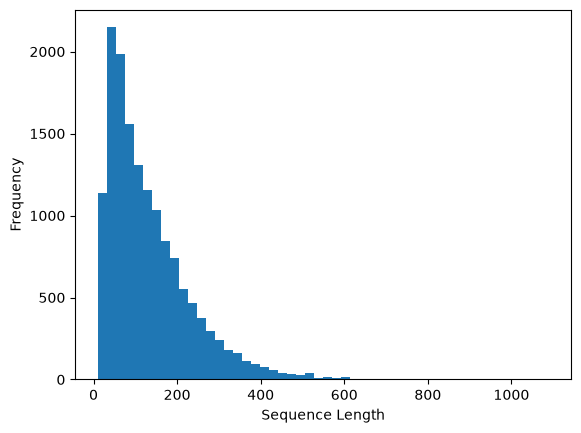

In [5]:
import matplotlib.pyplot as plt
import numpy as np

arr = np.array(lengths)
plt.hist(arr, bins=50)
plt.xlabel("Sequence Length")
plt.ylabel("Frequency")
plt.show()

In [6]:
def keep_example(example):
    src_len = len(tokenizer.encode(example["dialogue"]).ids)
    tgt_len = len(tokenizer.encode(example["summary"]).ids)

    return src_len <= 481 and tgt_len <= 65

filtered_train = train_sets.filter(keep_example)

Filter: 100%|██████████| 14731/14731 [00:02<00:00, 5104.67 examples/s]


In [7]:
import pandas as pd

df_train = pd.DataFrame(train_sets)
df_filtered_train = pd.DataFrame(filtered_train)
print(df_filtered_train.head())
print(df_filtered_train.shape)
print(df_filtered_train.columns)

print(df_train.shape)
print(df_train.columns)


         id                                           dialogue  \
0  13818513  Amanda: I baked  cookies. Do you want some?\nJ...   
1  13728867  Olivia: Who are you voting for in this electio...   
2  13681000  Tim: Hi, what's up?\nKim: Bad mood tbh, I was ...   
3  13730747  Edward: Rachel, I think I'm in ove with Bella....   
4  13728094  Sam: hey  overheard rick say something\nSam: i...   

                                             summary  
0  Amanda baked cookies and will bring Jerry some...  
1  Olivia and Olivier are voting for liberals in ...  
2  Kim may try the pomodoro technique recommended...  
3  Edward thinks he is in love with Bella. Rachel...  
4  Sam is confused, because he overheard Rick com...  
(14473, 3)
Index(['id', 'dialogue', 'summary'], dtype='str')
(14731, 3)
Index(['id', 'dialogue', 'summary'], dtype='str')


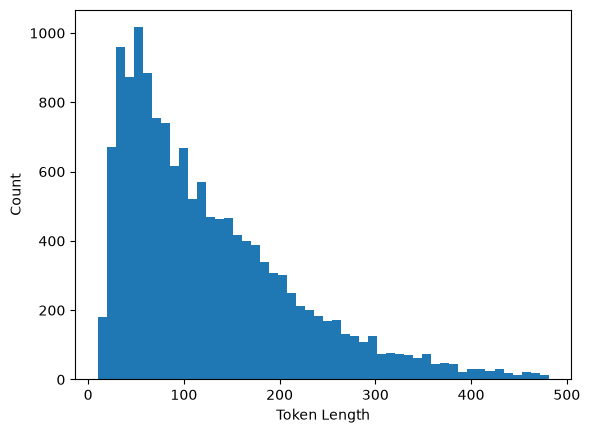

310.39999999999964
413.0
481


In [8]:
import matplotlib.pyplot as plt
import numpy as np

lengths = []
for item in filtered_train:
    lengths.append(len(tokenizer.encode(item["dialogue"]).ids))
lengths = np.array(lengths)

plt.hist(lengths, bins=50)
plt.xlabel("Token Length")
plt.ylabel("Count")
plt.show()


print(np.percentile(lengths, 95))
print(np.percentile(lengths, 99))
print(np.max(lengths))